## Day 9: Brownian Motion and Ito's Lemma

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
import statsmodels.tsa.arima.model as arima

In [17]:
df= pd.read_csv("datasets/oilgas.csv")[["Symbol", "Date", "Close"]]
df = df[df['Symbol'] == "Brent Oil"]

df

,Symbol,Date,Close
0,Brent Oil,2000-01-04,24.39
1,Brent Oil,2000-01-05,23.73
2,Brent Oil,2000-01-06,23.62
3,Brent Oil,2000-01-07,23.09
4,Brent Oil,2000-01-10,23.73
...,...,...,...
5763,Brent Oil,2022-06-13,122.27
5764,Brent Oil,2022-06-14,121.17
5765,Brent Oil,2022-06-15,118.51
5766,Brent Oil,2022-06-16,119.81


In [18]:
# Lets fine the current price of Brent Oil
print("The current price of Brent Oil is: $", df['Close'].iloc[-1])
# This will be our S0
S0 = df['Close'].iloc[-1]

The current price of Brent Oil is: $ 113.12


In [19]:
# # for our expected return we will use the average daily return
# mu = df['Close'].pct_change().mean()

# print("The average daily return of Brent Oil is: ", mu)

# # for our volatility we will use the standard deviation of the daily returns
# sigma = df['Close'].pct_change().std()
# print("The volatility of Brent Oil is: ", sigma)

# Better way to get the expected return and volatility, neglects the first NaN value
returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
mu = returns.mean()
sigma = returns.std()



In [20]:
# For the window we want to estimate, lets do 252 days (1 year)
window = 252

# We will use 10000 simulations
n_sims = 10000

# we will do a 1 day time step!
timestep = 1

In [21]:
# We will use the normal distribution to generate our random numbers
Z = np.random.normal(0, 1, (n_sims, window))
Z

array([[ 1.11248596, -1.22569319, -0.73080536, ..., -1.08629874,
        -0.07681153, -1.12405777],
       [-0.76783536, -0.17443107,  0.60033908, ...,  1.33322895,
         0.27569686,  0.99991183],
       [ 1.48338604,  0.80486496, -0.82636263, ..., -1.05706454,
        -0.74209173,  0.05918273],
       ...,
       [ 0.5835705 ,  0.89230772,  0.74178961, ..., -0.68456677,
         1.18682957,  0.55414556],
       [-1.12126872, -1.33829361, -0.33240658, ...,  0.55026922,
         0.77457289, -0.47043494],
       [-0.89997886,  0.6527602 ,  1.44703935, ...,  0.33704435,
        -0.4103534 , -0.38243348]])

In [22]:
# now to get a random daily shock, we will multiply it by the coefficient of the stdev * a square root of the timestep
shock = sigma * np.sqrt(timestep) * Z
shock


array([[ 0.02596334, -0.02860538, -0.01705563, ..., -0.02535218,
        -0.00179264, -0.0262334 ],
       [-0.01791984, -0.00407089,  0.01401079, ...,  0.03111507,
         0.00643425,  0.02333607],
       [ 0.03461945,  0.01878404, -0.01928576, ..., -0.02466991,
        -0.01731903,  0.00138121],
       ...,
       [ 0.01361944,  0.02082479,  0.01731198, ..., -0.01597651,
         0.02769838,  0.01293272],
       [-0.02616831, -0.03123327, -0.00775775, ...,  0.01284225,
         0.01807708, -0.01097907],
       [-0.02100382,  0.0152342 ,  0.03377119, ...,  0.00786598,
        -0.00957688, -0.00892528]])

In [23]:
# Adding deterministic drift
drift = (mu - 0.5 * sigma ** 2) * timestep
daily_returns = drift + shock
daily_returns

array([[ 0.02595705, -0.02861167, -0.01706192, ..., -0.02535847,
        -0.00179893, -0.02623969],
       [-0.01792613, -0.00407718,  0.0140045 , ...,  0.03110878,
         0.00642796,  0.02332978],
       [ 0.03461316,  0.01877775, -0.01929205, ..., -0.0246762 ,
        -0.01732532,  0.00137492],
       ...,
       [ 0.01361315,  0.0208185 ,  0.01730569, ..., -0.0159828 ,
         0.02769209,  0.01292643],
       [-0.0261746 , -0.03123956, -0.00776404, ...,  0.01283596,
         0.01807079, -0.01098536],
       [-0.02101011,  0.01522791,  0.0337649 , ...,  0.00785969,
        -0.00958317, -0.00893157]])

In [24]:
# # Now we will apply geometric Brownian motion to our price series
# price_paths = np.zeros((n_sims, window))
# price_paths[:, 0] = S0
# for i in range(n_sims):
#     price_paths[i] = price_paths[i] * np.exp(daily_returns)

# plt.figure(figsize=(10, 6))
# plt.plot(price_paths[0])
# plt.title("Price Paths of Brent Oil")
# plt.xlabel("Time")
# plt.ylabel("Price")
# plt.show()

In [25]:
cumulative_returns = np.cumsum(daily_returns, axis=1)

Text(0.5, 0, 'Time')

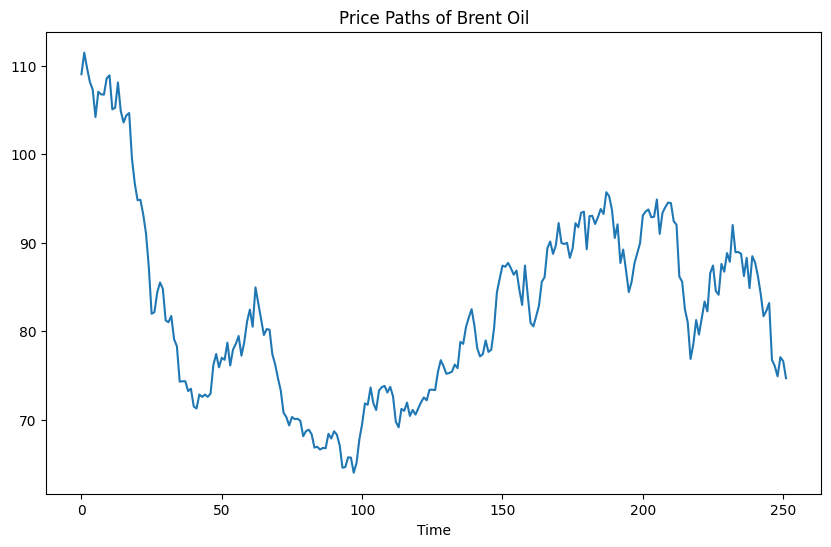

In [ ]:
# Since we vectorized it here, we can just do this, instead of for looping it!
price_paths = np.zeros((n_sims, window))
price_paths[:, 0] = S0
price_paths = S0 * np.exp(cumulative_returns)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(price_paths[0]) # Change this number to see different paths across the 10000 simulations!!!!!
plt.title("Price Paths of Brent Oil")
plt.xlabel("Time")
plt.ylabel("Price")

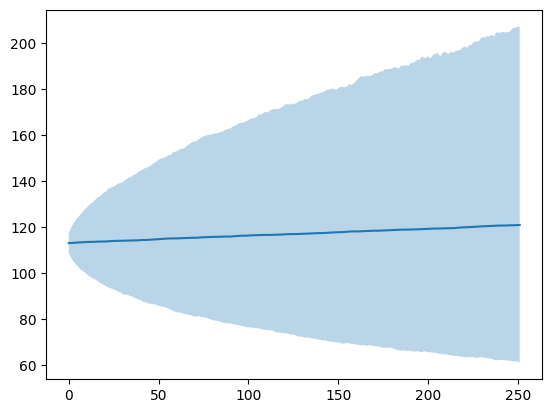

In [30]:
plt.plot(price_paths.mean(axis=0))  # average path
plt.fill_between(range(window),
                 np.percentile(price_paths, 5, axis=0),
                 np.percentile(price_paths, 95, axis=0),
                 alpha=0.3)

#### The expected trend of Brent Oil prices is upwards, driven by the drift term in the geometric Brownian motion. However, the confidence interval captures the uncertainty introduced by the stochastic shocks, which come from a normal distribution. This means that while the average path is upward-sloping, there remains a significant probability of downward movements. Importantly, because prices are modeled with an exponential of these shocks, the distribution of possible prices is lognormal rather than normal, producing an asymmetric spread around the mean.